In [1]:
suppressMessages({
    library(Seurat)
    library(ggplot2)
    library(GSEABase)
    library(dplyr)
    library(ggpubr)
    library(viridis)
    library("clusterProfiler")
    library("org.Hs.eg.db")
    library(dplyr)
})

# set.seed(123)

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘XML’ was built under R version 4.2.3”
Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘viridis’ was built under R version 4.2.3”


In [2]:
packageVersion("Seurat")
packageVersion("clusterProfiler")
packageVersion("GSEABase")
packageVersion("ggpubr")
packageVersion("org.Hs.eg.db")



[1] ‘4.3.0.1’

[1] ‘4.6.2’

[1] ‘1.60.0’

[1] ‘0.6.0’

[1] ‘3.16.0’

### 1.DEG

In [2]:
### 加载空间组seurat对象
seuobj = readRDS('/data/work/08.脑区划分/01.data/01.bin/AD_all.st.obj.1.rds')

In [3]:
### 标准化、归一化
### NormalizeData函数：去除测序通量差异
### ScaleData：Z-score转换，使所有基因可以放在一个维度进行比较
date()
seuobj = NormalizeData(seuobj) 
seuobj = FindVariableFeatures(seuobj, selection.method = "vst")
seuobj = ScaleData(seuobj)
date()

[1] "Sat Feb 28 20:37:41 2026"

Centering and scaling data matrix



[1] "Sat Feb 28 20:43:46 2026"

In [4]:
date()

[1] "Sat Feb 28 20:43:46 2026"

In [5]:
seuobj@meta.data[1,]

,orig.ident,nCount_RNA,nFeature_RNA,chip,nFeature_Spatial,nCount_Spatial,rx,ry,rx.m,ry.m,area
,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Con1.1_Con1.1_BIN100_357,Con1.1,2588,640,Con1.1,640,2588,0,0,0,611,Alveus


In [6]:
table(seuobj$area)


   Alveus       CA1   CA1_sub       CA2       CA3       CA4        DG   Fimbria 
    98534    148417     29655     16666     19037     62288     30897     50855 
    ML.DG     PL.DG        SL        SM     SM.DG        SO        SR Undefined 
    27168     27135     72592     46701      1758     62196     43516      8226 
      VES 
    19168 

In [7]:
table(seuobj$chip)


 AD1.1  AD1.2  AD2.1  AD2.2  AD3.1  AD3.2  AD4.1  AD4.2  AD5.1  AD5.2  AD6.1 
 13286  16064  30947  30845  17318  16746  21983  20339  19345  17203  32514 
 AD6.2  AD7.1  AD7.2  AD8.1  AD8.2 Con1.1 Con1.2 Con2.1 Con2.2 Con3.1 Con3.2 
 29286  28400  26854  18855  17933  30532  29587  23236  23639  27106  27294 
Con4.1 Con4.2 Con5.1 Con5.2 Con6.1 Con6.2 Con7.1 Con7.2 Con8.1 Con8.2 
 24598  24277  18074  17388  21506  21931  31648  29834  27468  28773 

In [8]:
seu1 = subset(seuobj,area == 'CA1')

In [9]:
seu1$group = gsub('\\d+','',seu1$chip)
seu1$group = gsub('\\.','',seu1$group)
table(seu1$group)


   AD   Con 
61530 86887 

In [10]:
getwd()

[1] "/data/work/10_protocol"

In [ ]:

Idents(seu1)="group"
DefaultAssay(seu1) = "RNA"
print('================ Start FindMarkers: ================')
date()
DE.gene <- FindMarkers(seu1, ident.1 = "AD",ident.2 = "Con", group.by = 'group')
DE.gene$gene = rownames(DE.gene)
DE.gene$cluster='CA1'
DE.gene$compare="AD-vs-Con"

DE.gene$max.pct = apply(DE.gene[,c("pct.1","pct.2")],1,max)
DE.gene$up.down = "No_Sig"
print('================ FindMarkers Finish: ================')
date()


saveRDS(DE.gene,'CA1.bin.AD_vs_Con.allgenes.rds' )
table(DE.gene$cluster)
DE.gene$max.pct = apply(DE.gene[,c("pct.1","pct.2")],1,max)
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1

DE.gene$up.down = "No_Sig"
DE.gene[which(DE.gene$max.pct> pct.filter & DE.gene$p_val_adj<adjPvalFilter & DE.gene$avg_log2FC>logFCfilter),'up.down'] = 'up'
DE.gene[which(DE.gene$max.pct> pct.filter & DE.gene$p_val_adj<adjPvalFilter & DE.gene$avg_log2FC< -logFCfilter),'up.down'] = 'down'

write.table(sig.markers,'CA1.bin.AD_vs_Con.allmarkers.txt',row.names = F,quote=F,sep="\t")

In [16]:
DE.gene[1,]

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,cluster,compare,max.pct,up.down
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
PRRT1,0,0.2513172,0.06,0.001,0,PRRT1,CA1,AD-vs-Con,0.06,No_Sig


### 1.2 火山图&热图

In [5]:
seuobj = readRDS('/data/work/08.脑区划分/01.data/01.bin/AD_all.st.obj.1.rds')
seuobj$group = gsub('\\d+','',seuobj$chip)
seuobj$group = gsub('\\.','',seuobj$group)
seuobj@meta.data[1,]

,orig.ident,nCount_RNA,nFeature_RNA,chip,nFeature_Spatial,nCount_Spatial,rx,ry,rx.m,ry.m,area,group
,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Con1.1_Con1.1_BIN100_357,Con1.1,2588,640,Con1.1,640,2588,0,0,0,611,Alveus,Con


In [6]:
seu1 = subset(seuobj,area == 'CA1')

In [7]:
date()

[1] "Thu Mar 26 15:37:40 2026"

In [8]:
sig.markers = readRDS('CA1.bin.AD_vs_Con.allgenes.rds')
table(sig.markers$up.down)
sig.markers[1,]


  down No_Sig     up 
    80  12985     99 

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,cluster,compare,max.pct,up.down
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
PRRT1,0,0.2513172,0.06,0.001,0,PRRT1,CA1,AD-vs-Con,0.06,No_Sig


In [21]:
-log10(cut_off_padj)

[1] 1.30103

In [47]:
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1

cut_off_log2FC = logFCfilter
cut_off_padj = adjPvalFilter

p = ggplot(sig.markers,aes(avg_log2FC,-log10(p_val_adj),
                color=factor(up.down) ))+  
  geom_point()+
  labs(x=expression(Log[2]*" Fold Change"),
       y=expression(-Log[10]*" (p value)"))+
  theme_classic(base_size = 15)+
  scale_color_manual(values = c('#3C5088','#dedae2','#A6443D') )+
  # scale_size_manual(values = c(2,1,2))+ 
  theme(legend.title = element_blank(),
        legend.background = element_rect(fill='transparent'))+
  geom_hline(yintercept = -log10(0.0001),linetype='longdash',cex=0.5)+  #添加辅助线
  geom_vline(xintercept = c(-cut_off_log2FC,cut_off_log2FC) ,linetype='longdash' ,cex=0.5)+
ggtitle('DEG volcano plot')+
  theme(axis.text= element_text(colour = "black"),
        panel.border = element_rect(size=1,fill='transparent') )
ggsave('DEG_volcano.pdf',p,width = 6,height = 5)

In [9]:
#### 热图
suppressMessages({
library(BayesSpace)
library(SingleCellExperiment)
library(ggplot2)
library(Seurat)
library(cowplot)
library(RColorBrewer)
library(getopt)
library(ComplexHeatmap)
library(viridis)
library(future)
library(dplyr)
library(Matrix)
library(data.table)
library(reshape2)
    
library(imager)
library(RColorBrewer)
library(Seurat)
library(ggplot2)
library(tidyr) 
})

Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.2.3”
Warning message:
“package ‘Matrix’ was built under R version 4.2.3”


In [10]:
sig.markers = sig.markers[which(sig.markers$up.down %in% c('up','down') ),]

In [11]:
table(seu1$group)


   AD   Con 
61530 86887 

In [ ]:
# cols = c('#4DAF4A',"#8dc7c2", "#e94c5f")
#total Sclerosis(-)和Sclerosis（+）

In [12]:
##计算gene表达均值

data = seu1@assays$RNA@data[sig.markers$gene,]
data = as.data.frame(t(as.data.frame(data,check.names=F)),check.names=F)
meta = seu1@meta.data
data = as.data.frame(scale(data),check.names=F)
#scale默认按列归一化

###################
gene_mean_df <- aggregate( data, by=list(meta$group), FUN=mean)
row.names(gene_mean_df) = gene_mean_df$Group.1
gene_mean_df = gene_mean_df[,-1]
# gene_mean_df[1:2,]

In [16]:
sig.markers = sig.markers[order(sig.markers$up.down,-sig.markers$avg_log2FC),]
annotation_row$up.down = factor(annotation_row$up.down,levels = c('up','down') )
annotation_row$gene = factor(annotation_row$gene,levels = sig.markers$gene )
annotation_row = annotation_row[order(annotation_row$up.down),]
annotation_row[1:2,]

df_plot = data.frame(t(gene_mean_df),check.names=F)
df_plot = df_plot[row.names(annotation_row),]##排序
df_plot = df_plot[, c('Con','AD') ]

row.type = data.frame(annotation_row$up.down)
row.names(row.type) = row.names(annotation_row)

ha = rowAnnotation(up.down = annotation_row$up.down ,col = list(up.down = c('up' = "#e94c5f", 'down' = "#8dc7c2") ) )

col_fun = circlize::colorRamp2(c(-1,0,1), c("#3C5088","white","#A6443D") )

p2 = Heatmap(df_plot ,cluster_rows = F,cluster_columns = F,row_split = row.type,
             left_annotation = ha,
             show_row_names = FALSE,
             col = col_fun,
             column_names_rot = 45,#x轴坐标斜度
             border = "black"
            )
p2

pdf('DEG.heatmp.pdf',width = 5,height = 6)
p2
dev.off()

,gene,up.down
,<fct>,<fct>
XIST,XIST,up
JUNB,JUNB,up


Warning message:
“The input is a data frame-like object, convert it to a matrix.”


png 
  2

In [11]:
table(seu1$group)


   AD   Con 
61530 86887 

In [ ]:
# cols = c('#4DAF4A',"#8dc7c2", "#e94c5f")
#total Sclerosis(-)和Sclerosis（+）

In [16]:
sig.markers = sig.markers[which(sig.markers$up.down %in% c('up','down') ),]
meta = seu1@meta.data
data = seu1@assays$RNA@data[sig.markers$gene,]
data = as.data.frame(t(as.data.frame(data,check.names=F)),check.names=F)
data = as.data.frame(scale(data),check.names=F)

gene_mean_df <- aggregate( data, by=list(meta$group), FUN=mean)
row.names(gene_mean_df) = gene_mean_df$Group.1
gene_mean_df = gene_mean_df[,-1]

sig.markers = sig.markers[order(sig.markers$up.down,-sig.markers$avg_log2FC),]
annotation_row$up.down = factor(annotation_row$up.down,levels = c('up','down') )
annotation_row$gene = factor(annotation_row$gene,levels = sig.markers$gene )
annotation_row = annotation_row[order(annotation_row$up.down),]
annotation_row[1:2,]

df_plot = data.frame(t(gene_mean_df),check.names=F)
df_plot = df_plot[row.names(annotation_row),]##排序
df_plot = df_plot[, c('Con','AD') ]

row.type = data.frame(annotation_row$up.down)
row.names(row.type) = row.names(annotation_row)

ha = rowAnnotation(up.down = annotation_row$up.down ,col = list(up.down = c('up' = "#e94c5f", 'down' = "#8dc7c2") ) )

col_fun = circlize::colorRamp2(c(-1,0,1), c("#3C5088","white","#A6443D") )

p2 = Heatmap(df_plot ,cluster_rows = F,cluster_columns = F,row_split = row.type,
             left_annotation = ha,
             show_row_names = FALSE,
             col = col_fun,
             column_names_rot = 45,#x轴坐标斜度
             border = "black"
            )
p2

pdf('DEG.heatmp.pdf',width = 5,height = 6)
p2
dev.off()

,gene,up.down
,<fct>,<fct>
XIST,XIST,up
JUNB,JUNB,up


Warning message:
“The input is a data frame-like object, convert it to a matrix.”


png 
  2

### 2.go

In [3]:
suppressMessages({
    library("clusterProfiler")
    library("org.Hs.eg.db")
    library(dplyr)
    library(stringr)
    
})

In [27]:
sig.markers = readRDS('CA1.bin.AD_vs_Con.allgenes.rds')
table(sig.markers$up.down)
sig.markers[1,]


down   up 
  80   99 

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,cluster,compare,max.pct,up.down
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
XIST,0,0.3451675,0.196,0.105,0,XIST,CA1,AD-vs-Con,0.196,up


In [30]:
sig.markers=sig.markers[sig.markers$up.down=="up",]
dim(sig.markers)
date()

mygene <-  AnnotationDbi::select(org.Hs.eg.db,columns=c("SYMBOL","ENTREZID"),keys=sig.markers$gene,keytype="SYMBOL") 
mygene <- mygene$ENTREZID
ego <- enrichGO(gene = mygene,OrgDb = org.Hs.eg.db,ont = "ALL",pAdjustMethod = "BH",pvalueCutoff = 1,qvalueCutoff = 1,readable = TRUE) 
GO <- ego@result 
GO$cluster = 'CA1'
date()


[1] 99 10

[1] "Mon Jan 19 17:12:42 2026"

'select()' returned 1:1 mapping between keys and columns



[1] "Mon Jan 19 17:13:09 2026"

In [32]:
GO.filter = GO[GO$p.adjust < 0.05,]
write.table(GO.filter,"GO.filter.txt",sep="\t",row.names=F,quote=F)
getwd()

[1] "/data/work/10_protocol"

In [33]:
GO.filter[1,]

,ONTOLOGY,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,cluster
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0010001,BP,GO:0010001,glial cell differentiation,12/92,227/18903,1.04715e-09,2.467086e-06,1.863928e-06,MT3/NKX6-2/ABCA2/NDRG1/VIM/CLU/GFAP/MAPT/CNP/SOX2/MAG/METRN,12,CA1


In [34]:
GO.filter[grepl('apoptotic',GO.filter$Description),]
#regulation of neuron apoptotic process

,ONTOLOGY,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,cluster
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0043281,BP,GO:0043281,regulation of cysteine-type endopeptidase activity involved in apoptotic process,10/92,205/18903,6.013617e-08,1.012006e-05,7.645885e-06,MT3/IFI6/NR4A1/CRYAB/MAPT/GSN/AQP1/SOX2/ST18/CCN1,10,CA1
GO:0043154,BP,GO:0043154,negative regulation of cysteine-type endopeptidase activity involved in apoptotic process,5/92,78/18903,3.903608e-05,1.438003e-03,1.086437e-03,MT3/IFI6/NR4A1/CRYAB/AQP1,5,CA1
GO:0042771,BP,GO:0042771,intrinsic apoptotic signaling pathway in response to DNA damage by p53 class mediator,4/92,44/18903,6.145142e-05,2.010827e-03,1.519216e-03,NUPR1/CD74/DDIT4/RPL26,4,CA1
GO:0008630,BP,GO:0008630,intrinsic apoptotic signaling pathway in response to DNA damage,5/92,102/18903,1.405168e-04,3.968074e-03,2.997951e-03,NUPR1/CD74/CLU/DDIT4/RPL26,5,CA1
GO:0072332,BP,GO:0072332,intrinsic apoptotic signaling pathway by p53 class mediator,4/92,81/18903,6.566146e-04,1.278499e-02,9.659289e-03,NUPR1/CD74/DDIT4/RPL26,4,CA1
GO:1902229,BP,GO:1902229,regulation of intrinsic apoptotic signaling pathway in response to DNA damage,3/92,38/18903,8.319293e-04,1.531270e-02,1.156902e-02,CD74/CLU/RPL26,3,CA1
GO:2001269,BP,GO:2001269,positive regulation of cysteine-type endopeptidase activity involved in apoptotic signaling pathway,2/92,10/18903,1.027946e-03,1.705522e-02,1.288553e-02,GSN/ST18,2,CA1
GO:1902165,BP,GO:1902165,regulation of intrinsic apoptotic signaling pathway in response to DNA damage by p53 class mediator,2/92,17/18903,3.038571e-03,3.254033e-02,2.458480e-02,CD74/RPL26,2,CA1
GO:2001267,BP,GO:2001267,regulation of cysteine-type endopeptidase activity involved in apoptotic signaling pathway,2/92,17/18903,3.038571e-03,3.254033e-02,2.458480e-02,GSN/ST18,2,CA1


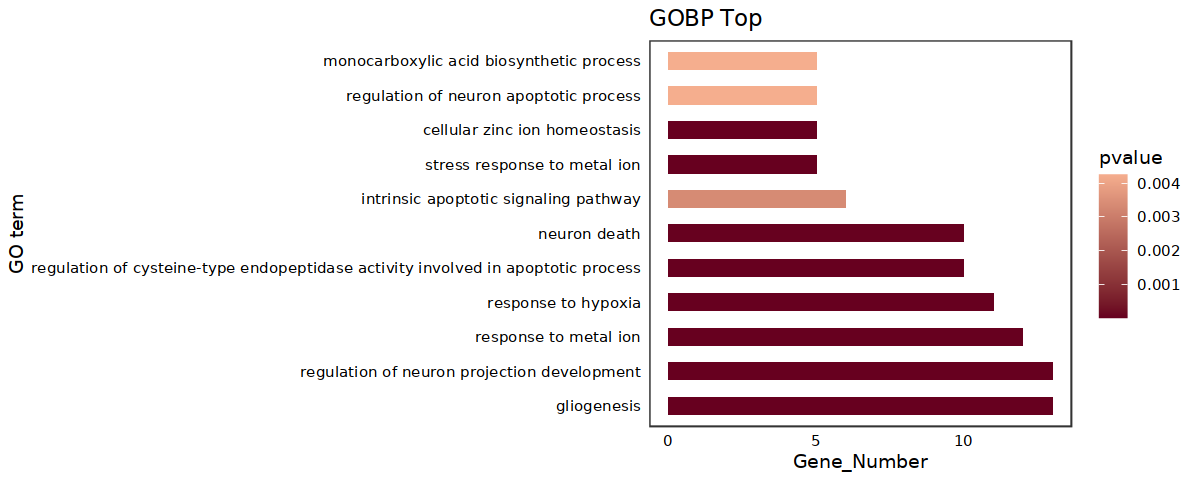

In [4]:
GO.filter = read.table("/data/work/10_protocol/for_plt.GO.filter_260326.txt",sep="\t",check.names=F,header=T,stringsAsFactors = FALSE,quote = "")
GO.combined.top.BP = GO.filter[GO.filter$ONTOLOGY=="BP",]
GO.combined.top.BP = GO.combined.top.BP %>% group_by(cluster) %>% top_n(10,Count)
GO.combined.top.BP = GO.combined.top.BP %>% group_by(cluster) %>% top_n(10,-pvalue)
GO.combined.top.BP = GO.combined.top.BP[order(GO.combined.top.BP$cluster,-GO.combined.top.BP$Count),]
GO.combined.top.BP$Description = factor(GO.combined.top.BP$Description,levels = unique(GO.combined.top.BP$Description))

library(viridis)
p1 = ggplot(GO.combined.top.BP,
       aes(x=Description,y=Count, fill=pvalue)) + #x、y轴定义；根据type填充颜色
       geom_bar(stat="identity", width=0.5) +  #柱状图宽度
       scale_fill_gradient(low = "#67001F", high = "#F5AE8E") +
       coord_flip() +  #让柱状图变为纵向
       xlab("GO term") +  #x轴标签
       ylab("Gene_Number") +  #y轴标签
       labs(title = 'GOBP Top')+  #设置标题
       theme_bw()+
       theme(panel.grid=element_blank(),
             axis.text.x = element_text(colour = "black"),
             axis.text.y = element_text(colour = "black"),
             # axis.text.y = element_blank(),
             axis.ticks.y = element_blank(),
             # axis.text.x = element_blank(),
             axis.ticks.x = element_blank()) 
options(repr.plot.height = 4,repr.plot.width = 10)
p1
# pdf("01.AD-up.GO-BP-term.top10.bubble.plot.pdf",width = 15,height = 15)#width = length(unique(combined.top$Description)),height = length(unique(combined.top$cluster)))
# print(p1)
# dev.off()

In [53]:
pdf("01.AD-up.GO-BP-term.top10.bubble.plot.pdf",width = 10,height = 6)#width = length(unique(combined.top$Description)),height = length(unique(combined.top$cluster)))
print(p1)
dev.off()

png 
  2

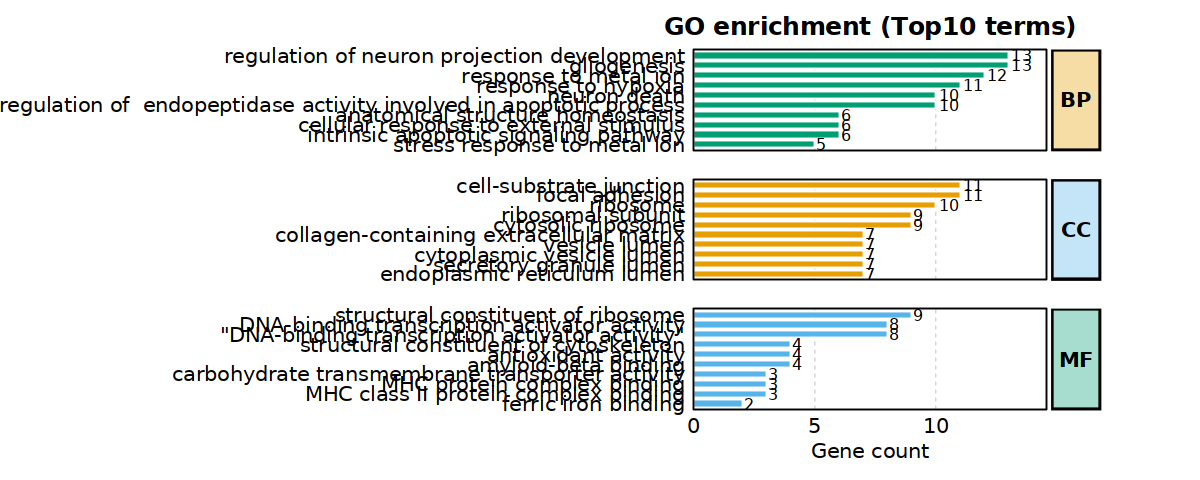

In [9]:

GO.filter_top10 <- GO.filter %>%
  group_by(ONTOLOGY) %>%
  arrange(ONTOLOGY, desc(Count)) %>%
  slice_head(n = 10) %>%
  ungroup()
GO.filter_top10$Description = gsub('cysteine-type','',GO.filter_top10$Description)
GO.filter_top10$Description = gsub(', RNA polymerase II-specific','',GO.filter_top10$Description)


# # 右侧分面标签背景色：与分组一致但更柔和（alpha.f 可调 0.25~0.5）
# strip_bg <- list(
#   BP = element_rect(fill = adjustcolor(okabe_ito["BP"], alpha.f = 0.35), color = "black", linewidth = 0.9),
#   CC = element_rect(fill = adjustcolor(okabe_ito["CC"], alpha.f = 0.35), color = "black", linewidth = 0.9),
#   MF = element_rect(fill = adjustcolor(okabe_ito["MF"], alpha.f = 0.35), color = "black", linewidth = 0.9)
# )
cols <- c(BP = "#E69F00", CC = "#56B4E9", MF = "#009E73")
# 定义 strip_bg
strip_bg <- list(
  BP = ggplot2::element_rect(fill = adjustcolor(cols["BP"], alpha.f = 0.35), 
                              color = "black", linewidth = 0.9),
  CC = ggplot2::element_rect(fill = adjustcolor(cols["CC"], alpha.f = 0.35), 
                              color = "black", linewidth = 0.9),
  MF = ggplot2::element_rect(fill = adjustcolor(cols["MF"], alpha.f = 0.35), 
                              color = "black", linewidth = 0.9)
)

GO.filter_top10 = GO.filter_top10[order(GO.filter_top10$Count),]
GO.filter_top10$Description = factor(GO.filter_top10$Description,levels = GO.filter_top10$Description)


p <- ggplot(GO.filter_top10, aes(x = Description, y =   Count, fill = ONTOLOGY)) +
  geom_col(width = 0.72, color = "white", linewidth = 0.4) +
  geom_text(aes(label = Count), hjust = -0.15, size = 3.3) +
  coord_flip(clip = "off") +
  ggh4x::facet_grid2(
    ONTOLOGY ~ .,
    scales = "free_y",
    space  = "free_y",
    drop   = FALSE,strip  = ggh4x::strip_themed(background_y = strip_bg)  
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.12))) +
  scale_fill_manual(values = c(BP = "#009E73", CC = "#E69F00", MF = "#56B4E9") ) +
  labs(
    x = NULL,
    y = "Gene count",
    title = "GO enrichment (Top10 terms)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_line(color = "grey", linewidth = 0.2,linetype = 2),
    
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.4),
    panel.spacing.y = unit(1.2, "lines"),
    
    strip.placement = "outside",
    strip.text.y.right = element_text(
      angle = 0, face = "bold", size = 12, color = "black",
      hjust = 0.5, vjust = 0.5
    ),
    strip.text.y.left = element_blank(),
    
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.text.y = element_text(size = 12,colour = "black"),
      axis.text.x = element_text(size = 12, colour = "black" ),# 设置y轴刻度文本颜色为黑色
    plot.margin = margin(10, 60, 10, 10)
  )
p


In [11]:
getwd()
pdf("GO.ONTOLOGY_split.pdf",width = 10,height = 10)#width = length(unique(combined.top$Description)),height = length(unique(combined.top$cluster)))
print(p)
dev.off()

[1] "/data/work/10_protocol"

png 
  2

### 3-4.GSEA

In [9]:
library(GSEABase)
library(dplyr)
library(ggpubr)
library(viridis)

Loading required package: annotate

Loading required package: XML

Warning message:
“package ‘XML’ was built under R version 4.2.3”
Loading required package: graph


Attaching package: ‘graph’


The following object is masked from ‘package:XML’:

    addNode




In [4]:
seuobj = readRDS('/data/work/08.脑区划分/01.data/01.bin/AD_all.st.obj.1.rds')
seuobj$group = gsub('\\d+','',seuobj$chip)
seuobj$group = gsub('\\.','',seuobj$group)

In [7]:
date()
seuobj = NormalizeData(seuobj) 
seuobj = FindVariableFeatures(seuobj, selection.method = "vst")
seuobj = ScaleData(seuobj)
date()

[1] "Thu Jan 22 09:56:04 2026"

Centering and scaling data matrix



[1] "Thu Jan 22 09:56:25 2026"

In [5]:
table(seuobj$chip)


 AD1.1  AD1.2  AD2.1  AD2.2  AD3.1  AD3.2  AD4.1  AD4.2  AD5.1  AD5.2  AD6.1 
 13286  16064  30947  30845  17318  16746  21983  20339  19345  17203  32514 
 AD6.2  AD7.1  AD7.2  AD8.1  AD8.2 Con1.1 Con1.2 Con2.1 Con2.2 Con3.1 Con3.2 
 29286  28400  26854  18855  17933  30532  29587  23236  23639  27106  27294 
Con4.1 Con4.2 Con5.1 Con5.2 Con6.1 Con6.2 Con7.1 Con7.2 Con8.1 Con8.2 
 24598  24277  18074  17388  21506  21931  31648  29834  27468  28773 

In [6]:
seuobj = subset(seuobj,chip %in% c('AD1.1','Con1.1') )

In [10]:
GO.filter = read.table("for_plt.GO.filter.txt",sep="\t",check.names=F,header=T,stringsAsFactors = FALSE,quote = "")
GO.combined.top.BP = GO.filter[GO.filter$ONTOLOGY=="BP",]
GO.combined.top.BP = GO.combined.top.BP %>% group_by(cluster) %>% top_n(10,-pvalue)
dim(GO.combined.top.BP)

[1] 10 11

In [6]:
GO.combined.top.BP$Description

[1] "gliogenesis"                                                                     
 [2] "regulation of neuron projection development"                                     
 [3] "response to metal ion"                                                           
 [4] "response to hypoxia"                                                             
 [5] "response to oxygen levels"                                                       
 [6] "regulation of cysteine-type endopeptidase activity involved in apoptotic process"
 [7] "stress response to metal ion"                                                    
 [8] "cellular zinc ion homeostasis"                                                   
 [9] "central nervous system myelination"                                              
[10] "axon ensheathment in central nervous system"

In [3]:
geneset <- getGmt("/data/work/02.file/file.13.c5.all.v2023.2.Hs.symbols.gmt")

In [4]:
geneset[[ which(names(geneset) == 'GOBP_APOPTOTIC_PROCESS' ) ]]

setName: GOBP_APOPTOTIC_PROCESS 
geneIds: AARS1, AATF, ..., ZSWIM2 (total: 1965)
geneIdType: Null
collectionType: Null 
details: use 'details(object)'

In [6]:
geneset[[ which(names(geneset) == 'GOBP_APOPTOTIC_PROCESS' ) ]]@geneIds

[1] "AARS1"           "AATF"            "ABL1"            "ABL2"           
   [5] "ACAA2"           "ACE"             "ACER2"           "ACIN1"          
   [9] "ACKR3"           "ACTB"            "ACTC1"           "ACTL6A"         
  [13] "ACTN1"           "ACTN2"           "ACTN3"           "ACTN4"          
  [17] "ACVR1"           "ACVR1B"          "ACVR1C"          "ADA"            
  [21] "ADAM15"          "ADAM17"          "ADAM8"           "ADAMTS20"       
  [25] "ADAMTSL4"        "ADAR"            "ADARB1"          "ADCY10"         
  [29] "ADIPOQ"          "ADM"             "ADNP"            "ADORA1"         
  [33] "ADORA2A"         "ADRA1A"          "AEN"             "AGAP2"          
  [37] "AGO4"            "AGT"             "AGTR2"           "AHCYL1"         
  [41] "AHI1"            "AHR"             "AIFM1"           "AIFM2"          
  [45] "AIFM3"           "AIMP1"           "AIMP2"           "AIPL1"          
  [49] "AKAP1"           "AKAP12"          "AKR1A1"          "AKR1B1"         
  [53] "AKR1C3"          "AKT1"            "AKT1S1"          "AKT2"           
  [57] "AKTIP"           "ALB"             "ALDH1A2"         "ALDH1A3"        
  [61] "ALK"             "ALKBH1"          "ALOX12"          "ALOX15B"        
  [65] "ALPK2"           "ALX3"            "ALX4"            "AMBRA1"         
  [69] "ANGPT1"          "ANGPT4"          "ANGPTL4"         "ANKLE2"         
  [73] "ANKRD1"          "ANKRD13C"        "ANO6"            "ANP32A"         
  [77] "ANP32B"          "ANP32C"          "ANP32E"          "ANXA1"          
  [81] "ANXA4"           "ANXA5"           "ANXA6"           "APAF1"          
  [85] "APBB1"           "APC"             "APEX1"           "API5"           
  [89] "APIP"            "APLP1"           "APOE"            "APOH"           
  [93] "APP"             "AQP1"            "AR"              "ARAF"           
  [97] "AREL1"           "ARF4"            "ARF6"            "ARG2"           
 [101] "ARHGAP10"        "ARHGDIA"         "ARHGEF2"         "ARHGEF6"        
 [105] "ARHGEF7"         "ARL6IP1"         "ARL6IP5"         "ARMC10"         
 [109] "ARMCX5-GPRASP2"  "ASAH2"           "ASCL1"           "ASIC2"          
 [113] "ASNS"            "ATAD3A"          "ATAD5"           "ATCAY"          
 [117] "ATF2"            "ATF3"            "ATF4"            "ATF5"           
 [121] "ATF6"            "ATG3"            "ATG4D"           "ATG5"           
 [125] "ATG7"            "ATM"             "ATN1"            "ATOH1"          
 [129] "ATP13A2"         "ATP2A1"          "ATP2A2"          "ATP2A3"         
 [133] "ATP5IF1"         "AURKA"           "AURKB"           "AVEN"           
 [137] "AVP"             "AXIN1"           "AXL"             "AZU1"           
 [141] "B4GALT1"         "BABAM2"          "BACE1"           "BAD"            
 [145] "BAG1"            "BAG3"            "BAG4"            "BAG5"           
 [149] "BAG6"            "BAK1"            "BAP1"            "BARD1"          
 [153] "BARHL1"          "BAX"             "BBC3"            "BCAP29"         
 [157] "BCAP31"          "BCAR1"           "BCL10"           "BCL11B"         
 [161] "BCL2"            "BCL2A1"          "BCL2L1"          "BCL2L10"        
 [165] "BCL2L11"         "BCL2L12"         "BCL2L13"         "BCL2L14"        
 [169] "BCL2L15"         "BCL2L2"          "BCL3"            "BCL6"           
 [173] "BCL7B"           "BCL7C"           "BCLAF1"          "BDKRB2"         
 [177] "BDNF"            "BECN1"           "BEX2"            "BEX3"           
 [181] "BFAR"            "BID"             "BIK"             "BIN1"           
 [185] "BIRC2"           "BIRC3"           "BIRC5"           "BIRC6"          
 [189] "BIRC7"           "BIRC8"           "BLCAP"           "BLID"           
 [193] "BLOC1S2"         "BMF"             "BMI1"            "BMP2"           
 [197] "BMP4"            "BMP5"            "BMP7"            "BMPR1A"         
 [201] "BMPR1B"          "BMPR2"           "BMX"     

In [9]:
gene_list = list( geneset[[ which(names(geneset) == 'GOBP_APOPTOTIC_PROCESS' ) ]]@geneIds )
names(gene_list) = "APOPTOTIC"

[1] "################## Start AUCell_buildRankings ##################"


[1] "Thu Jan 22 09:58:39 2026"

Quantiles for the number of genes detected by cell: 
(Non-detected genes are shuffled at the end of the ranking. Keep it in mind when choosing the threshold for calculating the AUC).



 min   1%   5%  10%  50% 100% 
 482  633  703  810 1568 3024 


Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“u

[1] "################## AUCell_buildRankings Finish ##################"


[1] "Thu Jan 22 10:00:27 2026"

Genes in the gene sets NOT available in the dataset: 
	APOPTOTIC: 	55 (3% of 1965)



[1] "################## AUCell_calcAUC Finish ##################"


[1] "Thu Jan 22 10:00:35 2026"

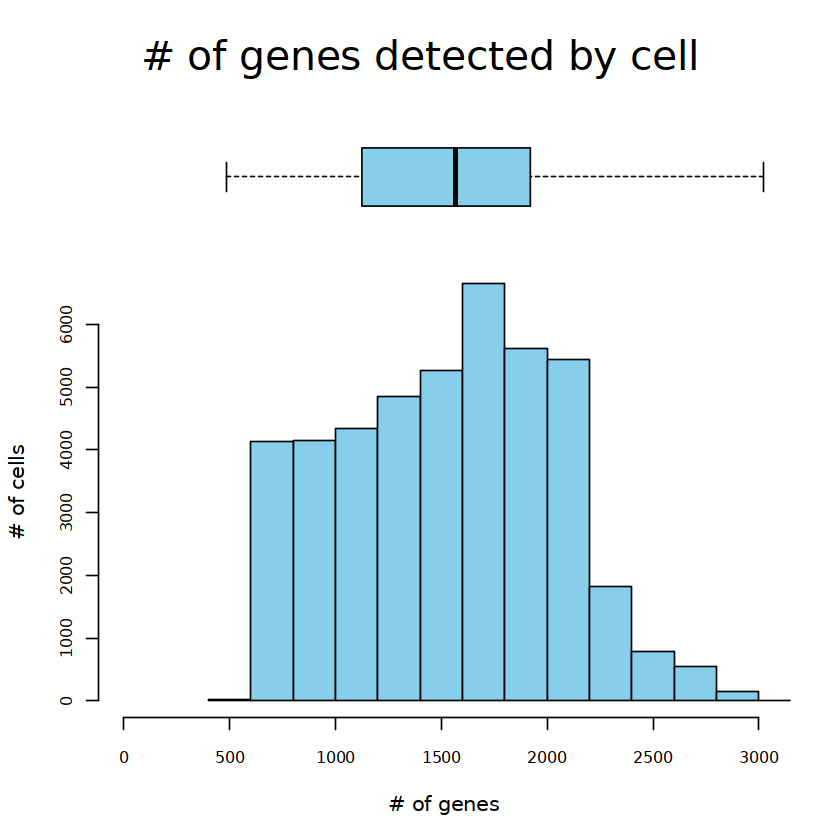

In [10]:
library(AUCell)
#cells_AUC <- AUCell_run(exprMatrix, geneSets)
print('################## Start AUCell_buildRankings ##################')
date()
cells_rankings <- AUCell_buildRankings(seuobj@assays$RNA@data,splitByBlocks=TRUE) 
print('################## AUCell_buildRankings Finish ##################')
date()

cells_AUC <- AUCell_calcAUC(gene_list, cells_rankings, 
                            aucMaxRank=nrow(cells_rankings)*0.1)
print('################## AUCell_calcAUC Finish ##################')
date()


In [13]:
AUC <- getAUC(cells_AUC)
AUC = data.frame(AUC,check.names=FALSE,check.rows=FALSE)
AUC = data.frame(t(AUC),check.names=F)
row.names(AUC)[1:5]
AUC[1:3,]

[1] "Con1.1_Con1.1_BIN100_357" "Con1.1_Con1.1_BIN100_358"
[3] "Con1.1_Con1.1_BIN100_359" "Con1.1_Con1.1_BIN100_360"
[5] "Con1.1_Con1.1_BIN100_361"

[1] 0.09617921 0.11193242 0.13310383

In [16]:
seuobj$Apoptotic = AUC$APOPTOTIC[match(row.names(seuobj@meta.data),row.names(AUC) )]

In [18]:
seuobj$group = gsub('\\d+','',seuobj$chip)
seuobj$group = gsub('\\.','',seuobj$group)

seuobj@meta.data[1,]

,orig.ident,nCount_RNA,nFeature_RNA,chip,nFeature_Spatial,nCount_Spatial,rx,ry,rx.m,ry.m,area,Apoptotic,group
,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
Con1.1_Con1.1_BIN100_357,Con1.1,2588,640,Con1.1,640,2588,0,0,0,611,Alveus,0.09617921,Con


In [14]:
head(AUC)

,APOPTOTIC
,<dbl>
Con1.1_Con1.1_BIN100_357,0.09617921
Con1.1_Con1.1_BIN100_358,0.11193242
Con1.1_Con1.1_BIN100_359,0.13310383
Con1.1_Con1.1_BIN100_360,0.11899657
Con1.1_Con1.1_BIN100_361,0.13561234
Con1.1_Con1.1_BIN100_362,0.11509507


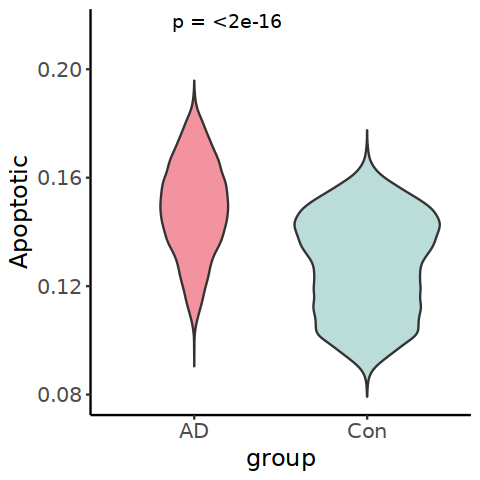

In [27]:
gp_color =  c("#8dc7c2", "#e94c5f")
names(gp_color) = c('Con','AD')

options(repr.plot.height = 4,repr.plot.width = 4)

ggplot(seuobj@meta.data, aes(x = group, y = Apoptotic, fill = group)) +
  geom_violin(
    alpha = 0.6, 
    width = 0.9,
    scale = "count",  # 统一最大宽度[1,3](@ref)
    trim = TRUE      # 保留密度曲线尾部[4](@ref)
  ) +
  scale_fill_manual(values = gp_color) +
  stat_compare_means(
    method = "wilcox.test",       # 或 "wilcox.test" 非参数检验[7](@ref)
    label = "p.format",      # 显示星号标记[8](@ref)
    label.y = max(seuobj@meta.data$Apoptotic, na.rm = TRUE) * 1.1  # 调整标签位置
  ) +
  theme_classic() +
  theme(
    legend.position = "none",  # 隐藏图例
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14)
  )

In [38]:
plasma <- viridis(10, direction = 1, option = "C")
coord <- data.frame(sp_1 = seuobj$rx.m, sp_2 = seuobj$ry.m)
seuobj[["sp"]] <- SeuratObject::CreateDimReducObject(embeddings = as.matrix(coord), key = "sp_", assay = "RNA")

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


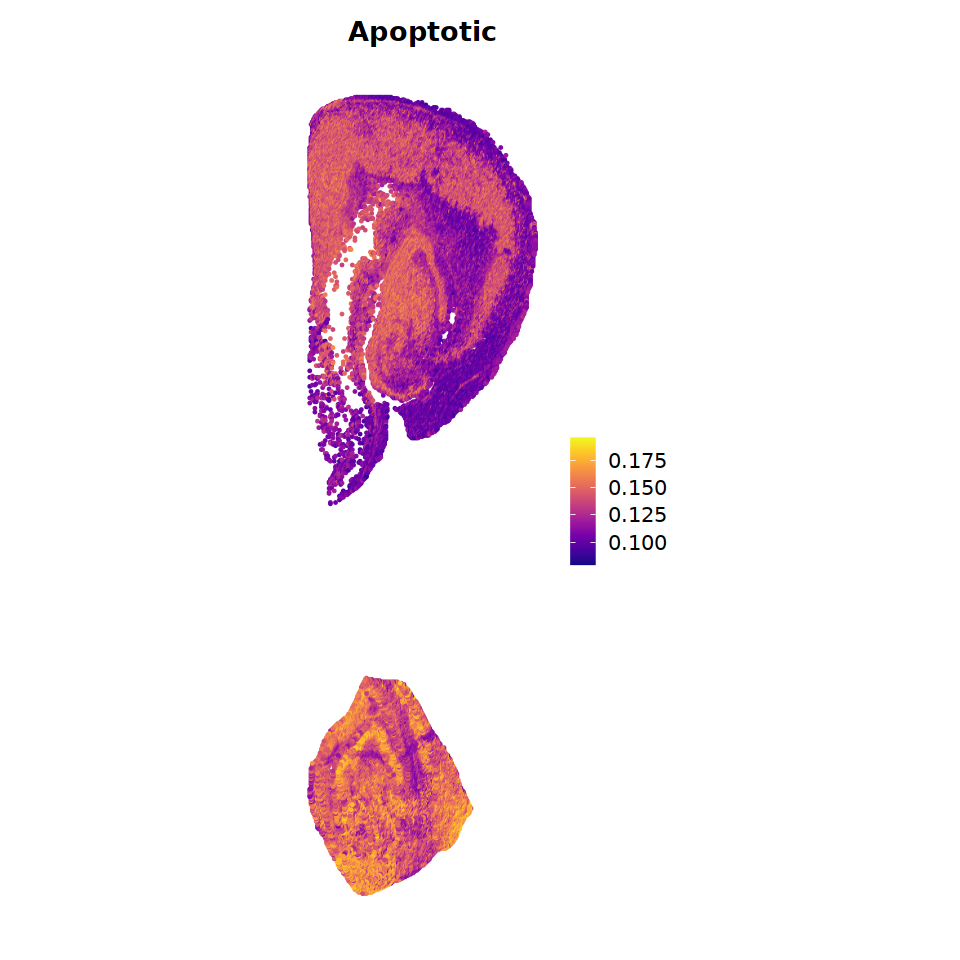

In [40]:
options(repr.plot.height = 8,repr.plot.width = 8)
FeaturePlot( seuobj , features = 'Apoptotic' ,reduction = "sp",pt.size = 0.3)+ scale_colour_gradientn(colours = plasma)+#scale_colour_gradientn(colours = plasma,limits = c(0, 3) )+
            # DarkTheme()+
            # labs(subtitle  = 'HS34')+
            theme(axis.line = element_blank(), axis.text = element_blank(), axis.ticks = element_blank(), axis.title = element_blank())+coord_fixed()